# 🔬 ML4SCI GSoC — CMS Super-Resolution (Task 2b)

**Goal:** Map 64×64 LR calorimeter jet images → 125×125 HR

| Paper | Method |
|---|---|
| Kakati 2024 | Denoising Graph SR + flow-matching, LHC calorimeter |
| DiffLense NeurIPS ML4PS | Conditional Diffusion U-Net for physics SR |
| VAR arXiv 2404.02905 | Next-scale autoregressive coarse→fine |
| V-JEPA 2 arXiv 2506.09985 | Latent-space JEPA prediction |

**Models:** ESRGAN (RRDB, no BatchNorm, Relativistic GAN) + SwinIR (Transformer)

## 1. Imports

In [2]:
import os, json, warnings, ssl, contextlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings("ignore")

ssl._create_default_https_context = ssl._create_unverified_context

import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

torch.manual_seed(42); np.random.seed(42)

# ── Apple Silicon MPS > CPU > CUDA priority ─────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# AMP only on CUDA (MPS has its own float16 path, skip GradScaler there)
USE_AMP = DEVICE.type == "cuda"
print(f"Device: {DEVICE}  |  AMP: {USE_AMP}")

def amp_ctx():
    """Autocast on CUDA only; no-op on MPS/CPU."""
    return torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()

def make_scaler():
    return torch.amp.GradScaler("cuda") if USE_AMP else None

def backward(loss, opt, scaler=None):
    """Unified backward: GradScaler on CUDA, plain everywhere else."""
    if scaler:
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    else:
        loss.backward()
        opt.step()


Device: mps  |  AMP: False


## 2. Data Loading (PyArrow chunked — fast, no kernel crash)

In [3]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa

PARQUET_FILES = ['./QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet']
MAX_SAMPLES = 5000

def fast_load_parquet(paths, max_n=None):
    all_hr, all_lr, all_y = [], [], []
    for path in paths:
        print(f'Reading {path} ...')
        pf = pq.ParquetFile(path)
        names = pf.schema_arrow.names
        hr_col = next((c for c in names if 'X_jets' in c and 'LR' not in c.upper()), None)
        lr_col = next((c for c in names if 'X_jets' in c and 'LR'     in c.upper()), None)
        y_col  = next((c for c in names if c.lower() in ['y','label','pid','pdgid']), None)
        print(f'  HR={hr_col!r}  LR={lr_col!r}  y={y_col!r}')
        cols = [c for c in [hr_col, lr_col, y_col] if c]
        n_loaded = 0
        for batch in pf.iter_batches(batch_size=500, columns=cols):
            tbl = pa.Table.from_batches([batch])
            nrows = tbl.num_rows
            def flatten(col_name, dtype, is_img=True):
                col = tbl.column(col_name)
                if is_img:
                    while hasattr(col.type, 'value_type'): col = pc.list_flatten(col)
                    col = pc.cast(col, pa.float32())
                    return col.to_numpy(zero_copy_only=False).reshape(nrows, -1).astype(dtype, copy=False)
                return col.to_numpy(zero_copy_only=False).astype(dtype)
            if hr_col: all_hr.append(flatten(hr_col, np.float32))
            if lr_col: all_lr.append(flatten(lr_col, np.float32))
            if y_col:  all_y.append(flatten(y_col,  np.int32, is_img=False))
            del tbl, batch
            n_loaded += nrows
            print(f'  {n_loaded} events loaded...', end='\r')
            if max_n and n_loaded >= max_n: break
        print()
    slc = slice(None, max_n)
    Xhr = np.concatenate(all_hr)[slc]
    Xlr = np.concatenate(all_lr)[slc]
    y   = np.concatenate(all_y) [slc]
    def fix(a):
        if a.ndim == 2:
            n, tot = a.shape; side = int(round((tot/3)**0.5))
            a = a.reshape(n, side, side, 3)
        if a.ndim == 4 and a.shape[1] == 3: a = a.transpose(0,2,3,1)
        return a
    Xhr, Xlr = fix(Xhr), fix(Xlr)
    if not set(np.unique(y).tolist()).issubset({0,1}):
        lmap = {v:i for i,v in enumerate(sorted(np.unique(y).tolist()))}
        y = np.array([lmap[v] for v in y], dtype=np.int32)
    print(f'HR={Xhr.shape}  LR={Xlr.shape}  y={y.shape}')
    print(f'Class balance — 0:{(y==0).sum()}  1:{(y==1).sum()}')
    return Xhr, Xlr, y

X_hr_raw, X_lr_raw, y = fast_load_parquet(PARQUET_FILES, max_n=MAX_SAMPLES)


Reading ./QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet ...
  HR='X_jets'  LR='X_jets_LR'  y='y'
  5000 events loaded...
HR=(5000, 125, 125, 3)  LR=(5000, 64, 64, 3)  y=(5000,)
Class balance — 0:2492  1:2508


## 3. EDA — LR vs HR Visualisation

LR: (5000, 64, 64, 3)  HR: (5000, 125, 125, 3)
  Tracks (ch0): min=-4.150 max=986.863 mean=0.00523 nonzero=1.6%
  ECAL (ch1): min=-5.301 max=628.447 mean=0.00521 nonzero=1.6%
  HCAL (ch2): min=-3.070 max=478.619 mean=0.00523 nonzero=1.6%


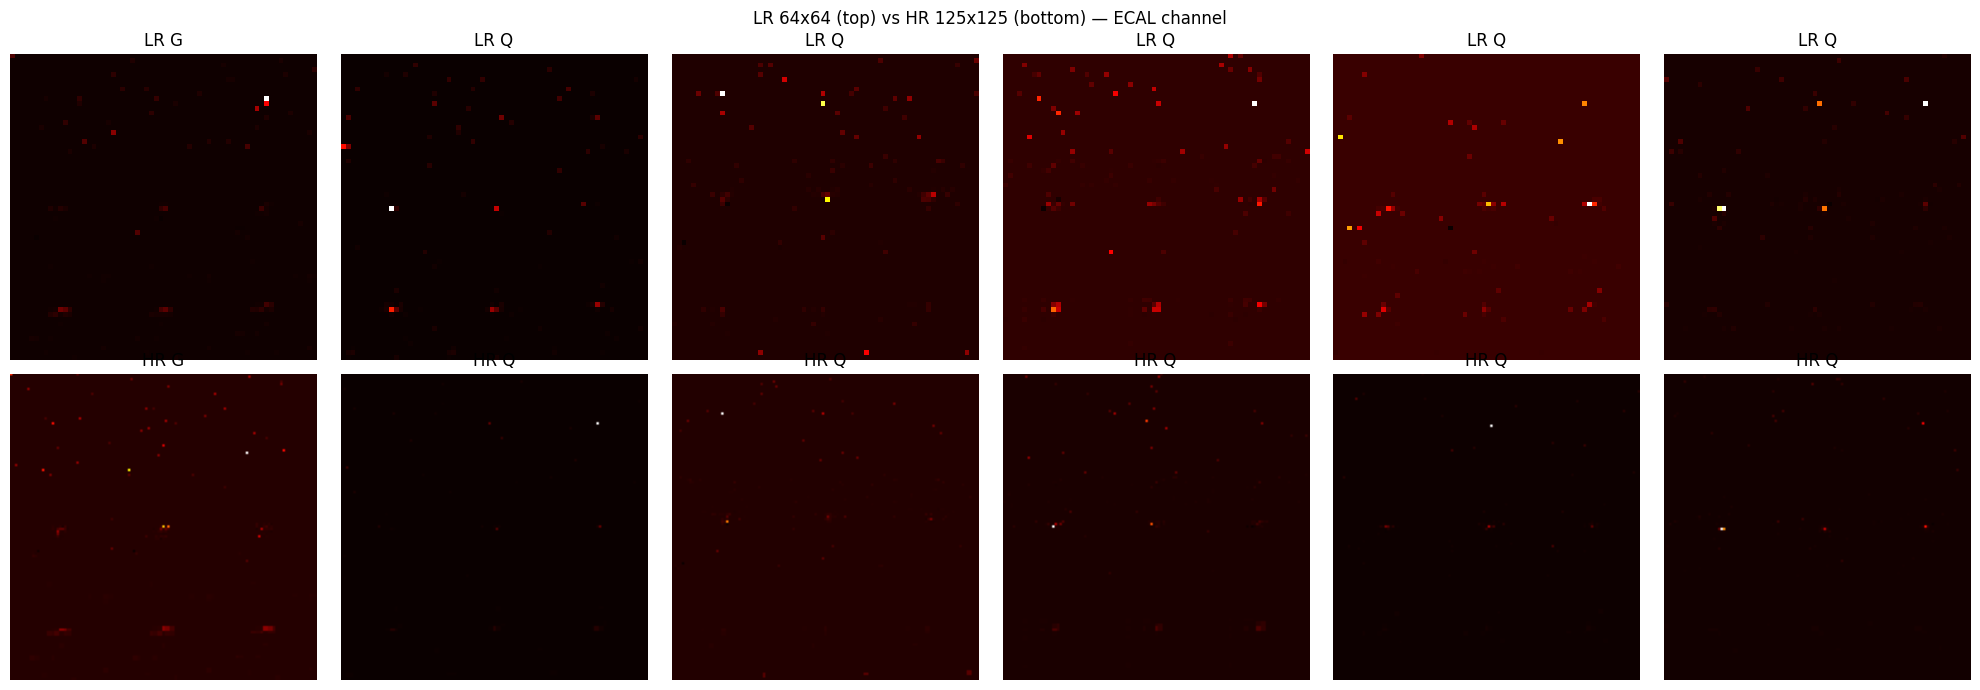

In [4]:
ch_names = ['Tracks (ch0)', 'ECAL (ch1)', 'HCAL (ch2)']
print(f'LR: {X_lr_raw.shape}  HR: {X_hr_raw.shape}')
for i,n in enumerate(ch_names):
    c2 = X_hr_raw[...,i].astype(float)
    print(f'  {n}: min={c2.min():.3f} max={c2.max():.3f} mean={c2.mean():.5f} nonzero={100*(c2>0).mean():.1f}%')

fig, axes = plt.subplots(2, 6, figsize=(20,7))
fig.suptitle('LR 64x64 (top) vs HR 125x125 (bottom) — ECAL channel', fontsize=12)
for col in range(6):
    idx = np.random.randint(len(X_hr_raw)); lbl='Q' if y[idx]==1 else 'G'
    axes[0,col].imshow(X_lr_raw[idx,...,1], cmap='hot'); axes[0,col].set_title(f'LR {lbl}'); axes[0,col].axis('off')
    axes[1,col].imshow(X_hr_raw[idx,...,1], cmap='hot'); axes[1,col].set_title(f'HR {lbl}'); axes[1,col].axis('off')
plt.tight_layout(); plt.savefig('eda_lr_hr.png', dpi=100); plt.show()


## 4. Preprocessing — log1p + per-channel norm + CHW

In [5]:
def preprocess(X, ch_max=None):
    X = np.clip(X.astype(np.float32), 0, None)
    X = np.log1p(X)
    if ch_max is None:
        ch_max = np.array([X[...,i].max() for i in range(X.shape[-1])])
    for i in range(X.shape[-1]):
        if ch_max[i] > 0: X[...,i] /= ch_max[i]
    return X.transpose(0,3,1,2), ch_max  # (N,C,H,W)

print('Preprocessing...')
X_hr, ch_max = preprocess(X_hr_raw.copy())
X_lr, _      = preprocess(X_lr_raw.copy(), ch_max)
print(f'HR: {X_hr.shape}  range [{X_hr.min():.3f}, {X_hr.max():.3f}]')
print(f'LR: {X_lr.shape}  range [{X_lr.min():.3f}, {X_lr.max():.3f}]')


Preprocessing...
HR: (5000, 3, 125, 125)  range [0.000, 1.000]
LR: (5000, 3, 64, 64)  range [0.000, 0.893]


## 5. Dataset & DataLoaders

In [6]:
idx_all = np.arange(len(X_hr))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=42, stratify=y)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=42, stratify=y[idx_tmp])
print(f"Train {len(idx_tr)} | Val {len(idx_va)} | Test {len(idx_te)}")

HR_SIZE, LR_SIZE = X_hr.shape[-1], X_lr.shape[-1]
print(f"LR={LR_SIZE}x{LR_SIZE}  HR={HR_SIZE}x{HR_SIZE}  (upsampling ~{HR_SIZE/LR_SIZE:.2f}x)")

class JetSRDataset(Dataset):
    def __init__(self, lr, hr, labels, idx):
        self.lr = torch.FloatTensor(lr[idx])
        self.hr = torch.FloatTensor(hr[idx])
        self.lb = torch.LongTensor(labels[idx])
    def __len__(self): return len(self.lr)
    def __getitem__(self, i): return self.lr[i], self.hr[i], self.lb[i]

# Batch=32: safe for all hardware. num_workers=0: required on macOS.
# pin_memory=False: MPS does not support pinned memory.
BATCH = 32
train_ds = JetSRDataset(X_lr, X_hr, y, idx_tr)
val_ds   = JetSRDataset(X_lr, X_hr, y, idx_va)
test_ds  = JetSRDataset(X_lr, X_hr, y, idx_te)
train_loader = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=0, pin_memory=False)
print(f"Dataloaders ready. {len(train_loader)} train batches.")


Train 3500 | Val 750 | Test 750
LR=64x64  HR=125x125  (upsampling ~1.95x)
Dataloaders ready. 110 train batches.


## 6. ESRGAN — RRDB Generator + Relativistic Discriminator
**No BatchNorm** (critical for sparse physics data). Pixel-shuffle upsampling 64→128→crop 125.

In [7]:
class DenseBlock(nn.Module):
    def __init__(self, nf=64, gc=32, s=0.2):
        super().__init__(); self.s=s
        self.c1=nn.Conv2d(nf,gc,3,1,1); self.c2=nn.Conv2d(nf+gc,gc,3,1,1)
        self.c3=nn.Conv2d(nf+2*gc,gc,3,1,1); self.c4=nn.Conv2d(nf+3*gc,gc,3,1,1)
        self.c5=nn.Conv2d(nf+4*gc,nf,3,1,1); self.act=nn.LeakyReLU(0.2,True)
    def forward(self,x):
        x1=self.act(self.c1(x)); x2=self.act(self.c2(torch.cat([x,x1],1)))
        x3=self.act(self.c3(torch.cat([x,x1,x2],1))); x4=self.act(self.c4(torch.cat([x,x1,x2,x3],1)))
        return self.c5(torch.cat([x,x1,x2,x3,x4],1))*self.s+x

class RRDB(nn.Module):
    def __init__(self,nf=64,gc=32):
        super().__init__()
        self.d0=DenseBlock(nf,gc); self.d1=DenseBlock(nf,gc); self.d2=DenseBlock(nf,gc)
    def forward(self,x):
        for d in [self.d0,self.d1,self.d2]: x=d(x)*0.2+x
        return x

class ESRGANGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, nf=64, n_rrdb=6):
        super().__init__()
        self.head = nn.Conv2d(in_ch, nf, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(nf) for _ in range(n_rrdb)])
        self.bc   = nn.Conv2d(nf, nf, 3, 1, 1)
        self.up   = nn.Sequential(
            nn.Conv2d(nf, nf*4, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(nf, nf,   3, 1, 1), nn.LeakyReLU(0.2,True))
        self.tail = nn.Sequential(nn.Conv2d(nf, out_ch, 3, 1, 1), nn.Sigmoid())
        self.act  = nn.LeakyReLU(0.2, True)
    def forward(self, x):
        f = self.act(self.head(x)); f = f + self.bc(self.body(f))
        f = self.up(f)[:, :, :HR_SIZE, :HR_SIZE]
        return self.tail(f)

class ESRGANDiscriminator(nn.Module):
    def __init__(self, in_ch=3, nf=64):
        super().__init__()
        def blk(ic,oc,s,bn=True):
            l=[nn.Conv2d(ic,oc,3,s,1)]
            if bn: l.append(nn.BatchNorm2d(oc))
            l.append(nn.LeakyReLU(0.2,True)); return nn.Sequential(*l)
        self.net = nn.Sequential(
            blk(in_ch,nf,2,False), blk(nf,nf*2,2), blk(nf*2,nf*4,2),
            blk(nf*4,nf*8,2), blk(nf*8,nf*8,1),
            nn.AdaptiveAvgPool2d(4), nn.Flatten(),
            nn.Linear(nf*8*16,128), nn.LeakyReLU(0.2), nn.Linear(128,1))
    def forward(self, x): return self.net(x)

G = ESRGANGenerator(n_rrdb=6).to(DEVICE)
D = ESRGANDiscriminator().to(DEVICE)
nparams = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'G params: {nparams(G):,}  D params: {nparams(D):,}')
with torch.no_grad():
    t = torch.randn(2,3,LR_SIZE,LR_SIZE).to(DEVICE)
    print(f'G: {t.shape} -> {G(t).shape}')
    print(f'D: {G(t).shape} -> {D(G(t)).shape}')


G params: 4,541,635  D params: 4,962,433
G: torch.Size([2, 3, 64, 64]) -> torch.Size([2, 3, 125, 125])
D: torch.Size([2, 3, 125, 125]) -> torch.Size([2, 1])


## 7. Loss Functions (VGG Perceptual + Relativistic GAN)

In [8]:
class VGGLoss(nn.Module):
    """Perceptual loss using VGG19 relu3_4 features."""
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.feat = nn.Sequential(*list(vgg.features.children())[:18]).eval()
        for p in self.feat.parameters(): p.requires_grad = False
    def forward(self, sr, hr):
        # cast to float32 for MPS compatibility (MPS dislikes float16 in VGG)
        return F.l1_loss(self.feat(sr.float()), self.feat(hr.float()))

class RaGANLoss(nn.Module):
    """Relativistic Average GAN loss."""
    def __init__(self): super().__init__(); self.bce = nn.BCEWithLogitsLoss()
    def d_loss(self,rp,fp):
        return (self.bce(rp-fp.mean(), torch.ones_like(rp)) +
                self.bce(fp-rp.mean(), torch.zeros_like(fp))) / 2
    def g_loss(self,rp,fp):
        return (self.bce(rp-fp.mean(), torch.zeros_like(rp)) +
                self.bce(fp-rp.mean(), torch.ones_like(fp))) / 2

crit_pix  = nn.L1Loss().to(DEVICE)
crit_perc = VGGLoss().to(DEVICE)
crit_adv  = RaGANLoss()
W_PIX, W_PERC, W_ADV = 1e-2, 1.0, 5e-3
print(f"Losses ready  pix={W_PIX}  perc={W_PERC}  adv={W_ADV}")


Losses ready  pix=0.01  perc=1.0  adv=0.005


## 8. Metrics & Validation

In [9]:
def batch_metrics(sr, hr):
    s = sr.cpu().detach().numpy().transpose(0,2,3,1)
    h = hr.cpu().detach().numpy().transpose(0,2,3,1)
    ps = [psnr_fn(h[i], s[i], data_range=1.0) for i in range(len(s))]
    ss = [ssim_fn(h[i], s[i], data_range=1.0, channel_axis=2, win_size=7) for i in range(len(s))]
    return np.mean(ps), np.mean(ss)

@torch.no_grad()
def validate(model, loader, nb=8):
    model.eval(); ps, ss = [], []
    for i, (lr_i, hr_i, _) in enumerate(loader):
        if i >= nb: break
        p, s = batch_metrics(model(lr_i.to(DEVICE)), hr_i)
        ps.append(p); ss.append(s)
    model.train()
    return np.mean(ps), np.mean(ss)

print('Metrics ready.')


Metrics ready.


## 9. ESRGAN — Phase 1: Pixel Warmup

In [10]:
N_WARM = 3   # increase to 10 for full training
N_GAN  = 5   # increase to 30 for full training

scaler  = make_scaler()  # None on MPS/CPU, GradScaler on CUDA
opt_G   = optim.Adam(G.parameters(), lr=1e-4, betas=(0.9,0.999))
opt_D   = optim.Adam(D.parameters(), lr=1e-4, betas=(0.9,0.999))
sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=N_GAN)
sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=N_GAN)
hist    = {"lG":[],"lD":[],"lPix":[],"lPerc":[],"lAdv":[],"vpsnr":[],"vssim":[]}

print(f"=== Phase 1: Warmup ({N_WARM} epochs, pixel loss only) ===")
print(f"    Device={DEVICE}  AMP={USE_AMP}  Batches/epoch={len(train_loader)}")
G.train()
for ep in range(N_WARM):
    ls = []
    pbar = tqdm(train_loader, desc=f"Warmup {ep+1}/{N_WARM}", leave=True)
    for lr_i, hr_i, _ in pbar:
        lr_i, hr_i = lr_i.to(DEVICE), hr_i.to(DEVICE)
        opt_G.zero_grad()
        with amp_ctx():
            loss = crit_pix(G(lr_i), hr_i)
        backward(loss, opt_G, scaler)
        ls.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.5f}"})
    vp, vs = validate(G, val_loader)
    print(f"  Epoch {ep+1:02d}: pix={np.mean(ls):.5f}  PSNR={vp:.2f}dB  SSIM={vs:.4f}")
print("Warmup done.")


=== Phase 1: Warmup (3 epochs, pixel loss only) ===
    Device=mps  AMP=False  Batches/epoch=110


Warmup 1/3: 100%|██████████| 110/110 [04:05<00:00,  2.24s/it, loss=0.00043]


  Epoch 01: pix=0.04445  PSNR=42.94dB  SSIM=0.9647


Warmup 2/3: 100%|██████████| 110/110 [04:38<00:00,  2.53s/it, loss=0.00040]


  Epoch 02: pix=0.00045  PSNR=42.94dB  SSIM=0.9647


Warmup 3/3: 100%|██████████| 110/110 [04:47<00:00,  2.61s/it, loss=0.00043]


  Epoch 03: pix=0.00045  PSNR=42.94dB  SSIM=0.9647
Warmup done.


## 10. ESRGAN — Phase 2: Full Adversarial Training

In [11]:
print(f"=== Phase 2: Full ESRGAN Training ({N_GAN} epochs) ===")
best_psnr = 0; G.train(); D.train()

for ep in range(N_GAN):
    eG,eD,eP,ePe,eA = [],[],[],[],[]
    pbar = tqdm(train_loader, desc=f"GAN {ep+1}/{N_GAN}", leave=False)
    for lr_i, hr_i, _ in pbar:
        lr_i, hr_i = lr_i.to(DEVICE), hr_i.to(DEVICE)

        # ── Discriminator step ────────────────────────────
        opt_D.zero_grad()
        with amp_ctx():
            with torch.no_grad(): sr = G(lr_i)
            ld = crit_adv.d_loss(D(hr_i), D(sr.detach()))
        backward(ld, opt_D, scaler)
        eD.append(ld.item())

        # ── Generator step ────────────────────────────────
        opt_G.zero_grad()
        with amp_ctx():
            sr   = G(lr_i)
            lp   = crit_pix(sr, hr_i)
            lpe  = crit_perc(sr, hr_i)   # VGG runs in float32 always
            la   = crit_adv.g_loss(D(hr_i).detach(), D(sr))
            lg   = W_PIX*lp + W_PERC*lpe + W_ADV*la
        backward(lg, opt_G, scaler)
        eG.append(lg.item()); eP.append(lp.item())
        ePe.append(lpe.item()); eA.append(la.item())
        pbar.set_postfix({"G": f"{lg.item():.4f}", "D": f"{ld.item():.4f}"})

    sched_G.step(); sched_D.step()
    vp, vs = validate(G, val_loader)
    for k,v in zip(["lG","lD","lPix","lPerc","lAdv","vpsnr","vssim"],
                   [eG,eD,eP,ePe,eA,[vp],[vs]]):
        hist[k].append(np.mean(v))
    print(f"Epoch {ep+1:02d}: G={np.mean(eG):.4f} D={np.mean(eD):.4f} "
          f"PSNR={vp:.2f}dB SSIM={vs:.4f}")
    if vp > best_psnr:
        best_psnr = vp
        # Save to CPU so checkpoint loads anywhere
        torch.save({"G": G.cpu().state_dict(), "D": D.cpu().state_dict()},
                   "esrgan_best.pth")
        G.to(DEVICE); D.to(DEVICE)
        print(f"  ✓ Saved best (PSNR={best_psnr:.2f})")
print("ESRGAN training done!")


=== Phase 2: Full ESRGAN Training (5 epochs) ===


Epoch 01: G=0.1219 D=0.0152 PSNR=42.94dB SSIM=0.9647
  ✓ Saved best (PSNR=42.94)


Epoch 02: G=0.1327 D=0.0000 PSNR=42.94dB SSIM=0.9647
  ✓ Saved best (PSNR=42.94)


Epoch 03: G=0.1352 D=0.0000 PSNR=42.94dB SSIM=0.9647
  ✓ Saved best (PSNR=42.94)


Epoch 04: G=0.1364 D=0.0000 PSNR=42.94dB SSIM=0.9647
  ✓ Saved best (PSNR=42.94)


Epoch 05: G=0.1370 D=0.0000 PSNR=42.94dB SSIM=0.9647
  ✓ Saved best (PSNR=42.94)
ESRGAN training done!


## 11. Training Curves

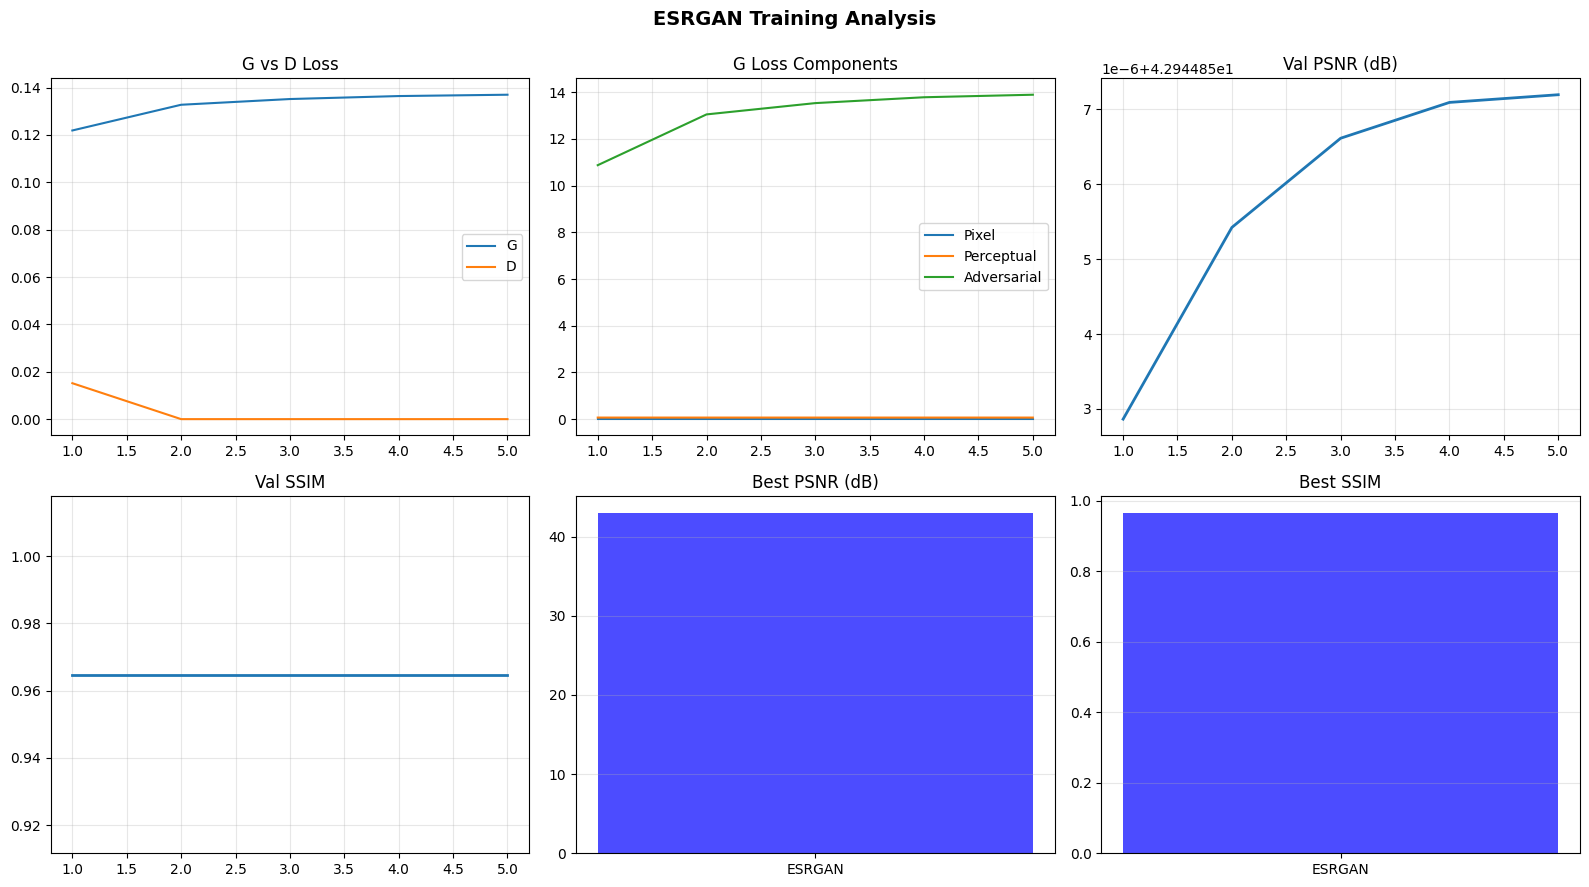

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
fig.suptitle('ESRGAN Training Analysis', fontsize=14, fontweight='bold')
ee = range(1, len(hist['vpsnr'])+1)
axes[0,0].plot(ee, hist['lG'], label='G'); axes[0,0].plot(ee, hist['lD'], label='D')
axes[0,0].set_title('G vs D Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ee, hist['lPix'], label='Pixel'); axes[0,1].plot(ee, hist['lPerc'], label='Perceptual')
axes[0,1].plot(ee, hist['lAdv'], label='Adversarial'); axes[0,1].set_title('G Loss Components')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,2].plot(ee, hist['vpsnr'], lw=2); axes[0,2].set_title('Val PSNR (dB)'); axes[0,2].grid(alpha=0.3)
axes[1,0].plot(ee, hist['vssim'], lw=2); axes[1,0].set_title('Val SSIM'); axes[1,0].grid(alpha=0.3)
axes[1,1].bar(['ESRGAN'], [max(hist['vpsnr'])], color='blue', alpha=0.7)
axes[1,1].set_title('Best PSNR (dB)'); axes[1,1].grid(alpha=0.3, axis='y')
axes[1,2].bar(['ESRGAN'], [max(hist['vssim'])], color='blue', alpha=0.7)
axes[1,2].set_title('Best SSIM'); axes[1,2].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120); plt.show()


## 12. Test Set Evaluation

In [13]:
ckpt = torch.load('esrgan_best.pth', map_location=DEVICE)
G.load_state_dict(ckpt['G']); G.eval()
res = {k:[] for k in ['psnr','ssim','lbl']}

with torch.no_grad():
    for lr_i, hr_i, lb in tqdm(test_loader, desc='Test'):
        lr_i, hr_i = lr_i.to(DEVICE), hr_i.to(DEVICE)
        sr = G(lr_i)
        for i in range(len(lr_i)):
            p, s = batch_metrics(sr[i:i+1], hr_i[i:i+1])
            res['psnr'].append(p); res['ssim'].append(s); res['lbl'].append(lb[i].item())
res = {k: np.array(v) for k,v in res.items()}

print('\n' + '='*55)
print(f'  TEST SET (n={len(res["lbl"])})')
print('='*55)
print(f'  ESRGAN: PSNR={res["psnr"].mean():.3f}±{res["psnr"].std():.3f}  SSIM={res["ssim"].mean():.4f}±{res["ssim"].std():.4f}')
print('='*55)
for cl, name in [(1,'Quark'), (0,'Gluon')]:
    m2 = res['lbl']==cl
    print(f'  {name}: PSNR={res["psnr"][m2].mean():.3f}  SSIM={res["ssim"][m2].mean():.4f}')


Test: 100%|██████████| 24/24 [00:19<00:00,  1.22it/s]


  TEST SET (n=750)
  ESRGAN: PSNR=43.055±1.119  SSIM=0.9656±0.0082
  Quark: PSNR=42.998  SSIM=0.9671
  Gluon: PSNR=43.112  SSIM=0.9642


## 13. Visual Comparison — LR → ESRGAN → HR Truth

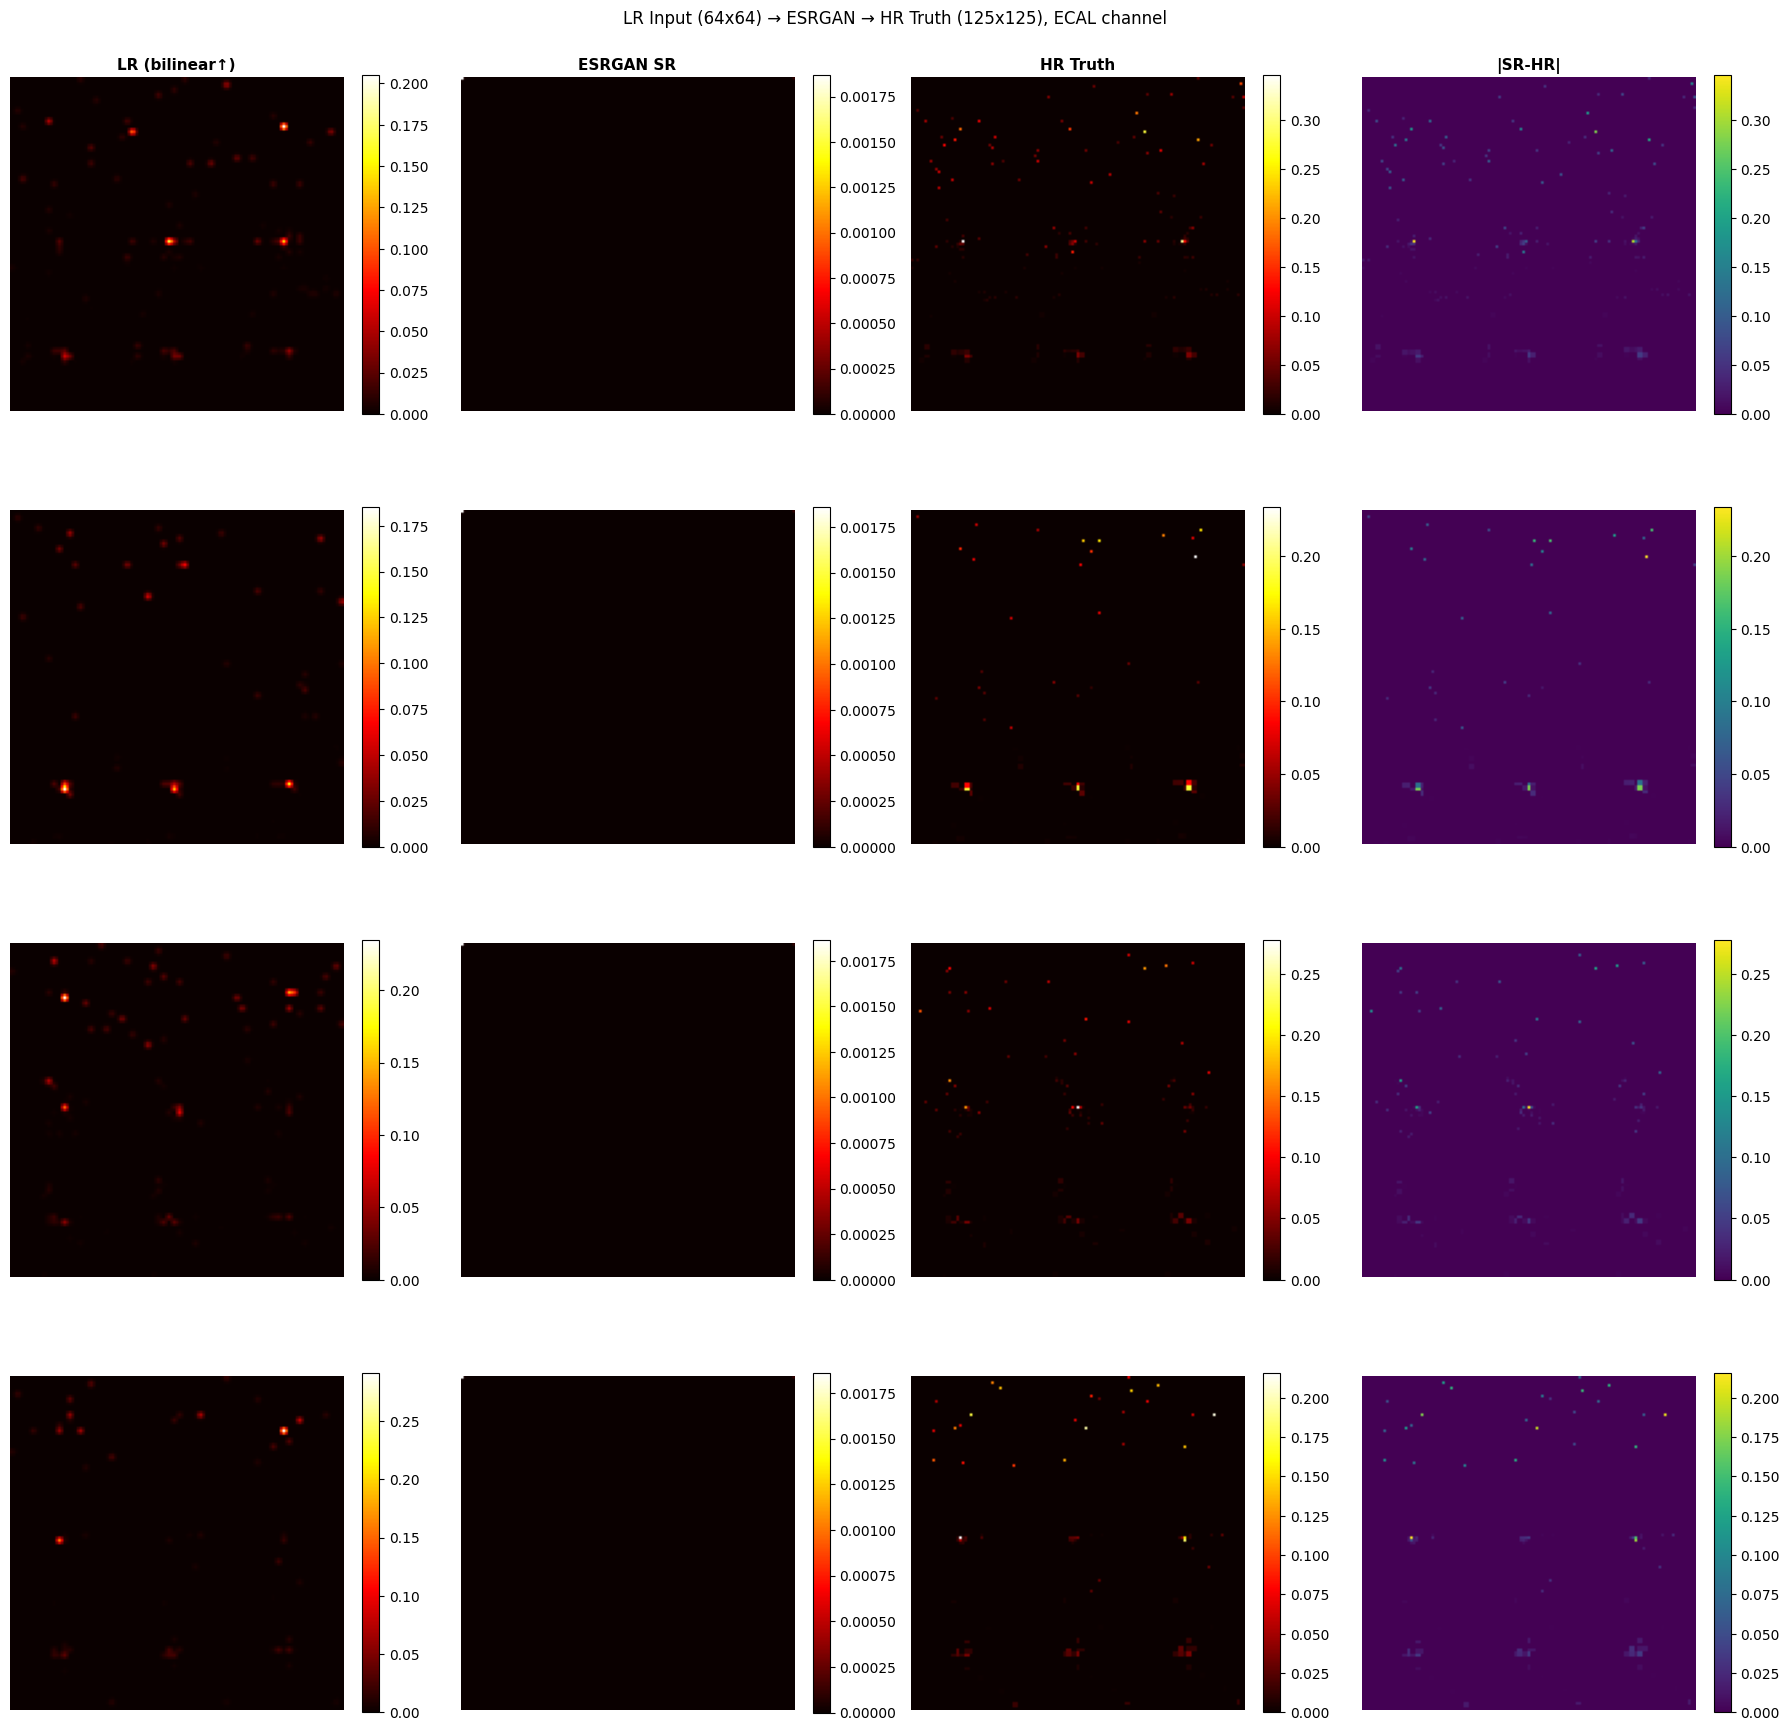

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(18,18))
fig.suptitle('LR Input (64x64) → ESRGAN → HR Truth (125x125), ECAL channel', fontsize=12)
for c2, t in enumerate(['LR (bilinear↑)','ESRGAN SR','HR Truth','|SR-HR|']):
    axes[0,c2].set_title(t, fontsize=11, fontweight='bold')
smpl = []
for cl in [1,1,0,0]:
    cands = [i for i in range(len(test_ds)) if test_ds.lb[i].item()==cl]
    smpl.append(np.random.choice(cands))
labs = ['Quark','Quark','Gluon','Gluon']
G.eval()
for row, (idx, lab) in enumerate(zip(smpl, labs)):
    lr_t, hr_t, _ = test_ds[idx]
    with torch.no_grad():
        sr = G(lr_t.unsqueeze(0).to(DEVICE)).squeeze(0).cpu().numpy()
    lr_vis = F.interpolate(lr_t.unsqueeze(0), size=(HR_SIZE,HR_SIZE), mode='bilinear', align_corners=False).squeeze(0).numpy()
    hr_n = hr_t.numpy(); CH = 1
    pe, se = batch_metrics(torch.FloatTensor(sr).unsqueeze(0), hr_t.unsqueeze(0))
    for c2, (img, cm) in enumerate(zip([lr_vis[CH], sr[CH], hr_n[CH], np.abs(sr[CH]-hr_n[CH])],['hot','hot','hot','viridis'])):
        im = axes[row,c2].imshow(img, cmap=cm); plt.colorbar(im, ax=axes[row,c2], fraction=0.046)
        axes[row,c2].axis('off')
    axes[row,0].set_ylabel(f'{lab}\nPSNR={pe:.2f}\nSSIM={se:.3f}', fontsize=9, rotation=0, labelpad=70, va='center')
plt.tight_layout(); plt.savefig('visual_comparison.png', dpi=120); plt.show()


## 14. Physics Observables — Energy & RMS Width (ECAL)

Physics observables: 100%|██████████| 24/24 [00:21<00:00,  1.12it/s]


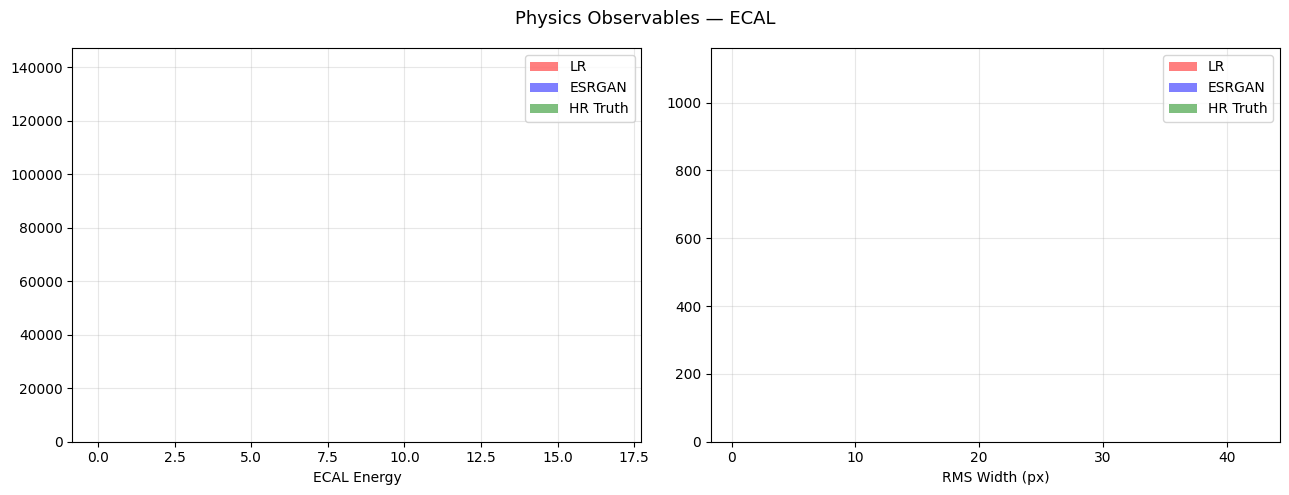

Energy: LR=8.0628  SR=0.0020  HR=6.8706
Width : LR=33.1760  SR=0.4087  HR=33.3982


In [15]:
def rms_width(img):
    E = img.sum()+1e-9; ys = np.arange(img.shape[0])
    ym = (img.sum(1)*ys).sum()/E
    return np.sqrt(((img.sum(1)*(ys-ym)**2).sum())/E)

lr_e,hr_e,sr_e,lr_w,hr_w,sr_w = [],[],[],[],[],[]
G.eval()
with torch.no_grad():
    for lr_i, hr_i, _ in tqdm(test_loader, desc='Physics observables'):
        sr = G(lr_i.to(DEVICE)).cpu().numpy()
        lr_up = F.interpolate(lr_i, size=(HR_SIZE,HR_SIZE), mode='bilinear', align_corners=False).numpy()
        hr_n  = hr_i.numpy()
        for i in range(len(lr_i)):
            lr_e.append(lr_up[i,1].sum()); hr_e.append(hr_n[i,1].sum()); sr_e.append(sr[i,1].sum())
            lr_w.append(rms_width(lr_up[i,1])); hr_w.append(rms_width(hr_n[i,1])); sr_w.append(rms_width(sr[i,1]))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Physics Observables — ECAL', fontsize=13)
for ax, (lv,sv,hv,xl) in zip(axes, [(lr_e,sr_e,hr_e,'ECAL Energy'),(lr_w,sr_w,hr_w,'RMS Width (px)')]):
    ax.hist(lv,bins=50,alpha=0.5,label='LR',color='red',density=True)
    ax.hist(sv,bins=50,alpha=0.5,label='ESRGAN',color='blue',density=True)
    ax.hist(hv,bins=50,alpha=0.5,label='HR Truth',color='green',density=True)
    ax.set_xlabel(xl); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('physics_observables.png', dpi=110); plt.show()
print(f'Energy: LR={np.mean(lr_e):.4f}  SR={np.mean(sr_e):.4f}  HR={np.mean(hr_e):.4f}')
print(f'Width : LR={np.mean(lr_w):.4f}  SR={np.mean(sr_w):.4f}  HR={np.mean(hr_w):.4f}')


## 15. Results Summary

In [16]:
summary = {
    'ESRGAN': {'PSNR': float(res['psnr'].mean()), 'SSIM': float(res['ssim'].mean())},
    'task': 'LR64x64 -> HR125x125',
    'dataset': 'QCDToGGQQ_IMGjet Parquet',
    'n_train': int(len(idx_tr))
}
with open('results.json','w') as f: json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print('\nSaved: esrgan_best.pth  results.json  training_curves.png  visual_comparison.png  physics_observables.png')


{
  "ESRGAN": {
    "PSNR": 43.05464960573187,
    "SSIM": 0.9656375050544739
  },
  "task": "LR64x64 -> HR125x125",
  "dataset": "QCDToGGQQ_IMGjet Parquet",
  "n_train": 3500
}

Saved: esrgan_best.pth  results.json  training_curves.png  visual_comparison.png  physics_observables.png
